In [ ]:
# Graph Autoencoder (GAE) Training
# This notebook trains a Graph Autoencoder on the knowledge base datasets (PPMI + Neurocon) to learn meaningful graph embeddings.

# **Purpose:**
# - Train an encoder that maps brain connectivity graphs to a 128-dimensional embedding space
# - The encoder learns to capture structural patterns in functional connectivity
# - These learned representations will be used for retrieval in the RAC model

# Import necessary libraries
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.loader import DataLoader
from utils import FCDataset
from importlib import reload
import models
reload(models)  # Reload models module to capture any code changes
from models import GraphAutoencoder

# ===== LOAD DATA =====
# Define paths to output directory and master metadata file
output_dir = r'C:\Users\danie\Documents\Projects\Master thesis\Tara\Scripts\Outputs'
master_csv = os.path.join(output_dir, "master_metadata.csv")

# Load the master metadata CSV created in Script 01
df = pd.read_csv(master_csv)

# ===== FILTER FOR KNOWLEDGE BASE =====
# Extract only PPMI and Neurocon datasets to form the knowledge base
# TaoWu is reserved as the target dataset for evaluation
df_kb = df[df['dataset_source'].isin(['PPMI', 'Neurocon'])].reset_index(drop=False)

# Preserve original index for later reference
df_kb = df_kb.rename(columns={'index': 'original_master_index'})

print(f"Total Knowledge Base samples: {len(df_kb)}")
print(df_kb.head())

# ===== CREATE DATALOADER =====
# FCDataset converts each subject's FC matrix into a PyTorch Geometric graph
# Each 100x100 correlation matrix becomes a graph with 100 nodes and weighted edges
kb_dataset = FCDataset(df_kb)

# DataLoader batches multiple graphs together for efficient training
# batch_size=32: Process 32 brain graphs at once
# shuffle=True: Randomize order each epoch to prevent overfitting
kb_dataloader = DataLoader(kb_dataset, batch_size=32, shuffle=True)

# ===== INITIALIZE MODEL AND TRAINING COMPONENTS =====
# Initialize Graph Autoencoder
# - num_nodes=100: Schaefer 100 parcellation (100 brain regions)
# - input_dim=100: Identity matrix features (one-hot encoding of nodes)
# - hidden_dim=64: Intermediate representation size
# - embedding_dim=128: Final embedding dimensionality (this is what we'll use for retrieval)
model = GraphAutoencoder(num_nodes=100, input_dim=100, hidden_dim=64, embedding_dim=128)

# Initialize optimizer with weight decay for regularization
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)

# Loss function: Mean Squared Error between original and reconstructed matrices
loss_fn = torch.nn.MSELoss()

num_epochs = 100
print("Starting GAE Training...")
train_losses = []

# ===== TRAINING LOOP =====
for epoch in range(num_epochs):
    model.train()  # Set model to training mode (enables dropout, etc.)
    total_loss = 0
    valid_batches = 0
    
    # Iterate through batches of brain graphs
    for batch_idx, (data, label) in enumerate(kb_dataloader):
        optimizer.zero_grad()  # Reset gradients from previous iteration
        
        try:
            # ===== PREPARE TARGET =====
            # data.y contains the flattened upper triangle of the correlation matrix
            # Reshape to (batch_size, 100, 100) for reconstruction loss
            target = data.y.view(data.num_graphs, 100, 100)
            
            # ===== FORWARD PASS =====
            # Pass graph through autoencoder
            # Input: node features (x), edge connections (edge_index), edge weights (edge_weight), batch assignment
            # Output: reconstructed 100x100 correlation matrix
            reconstructed = model(data.x, data.edge_index, data.edge_weight, data.batch)
            
            # ===== CHECK FOR NUMERICAL ISSUES =====
            # Skip batch if NaN or Inf values appear (indicates training instability)
            if torch.isnan(reconstructed).any() or torch.isinf(reconstructed).any():
                print(f"Epoch {epoch+1}, Batch {batch_idx}: NaN/Inf detected")
                continue
            
            # ===== CALCULATE LOSS =====
            # Compare reconstructed matrix with original matrix
            loss = loss_fn(reconstructed, target)
            
            # ===== BACKWARD PASS =====
            loss.backward()  # Compute gradients
            
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()  # Update model weights
            
            total_loss += loss.item()
            valid_batches += 1
            
        except Exception as e:
            print(f"Error in batch {batch_idx}: {e}")
            continue
    
    # ===== EPOCH SUMMARY =====
    if valid_batches > 0:
        avg_loss = total_loss / valid_batches
        train_losses.append(avg_loss)
        # Print progress every 5 epochs
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:03d}/{num_epochs} | Loss: {avg_loss:.6f}")

# ===== SAVE TRAINED ENCODER =====
# Save only the encoder weights (not the decoder)
# The encoder is what we'll use to create embeddings for retrieval
encoder_path = os.path.join(output_dir, 'gae_encoder.pth')
torch.save(model.encoder.state_dict(), encoder_path)
print(f"GAE Training Complete. Encoder weights saved to: {encoder_path}")

# ===== VISUALIZATION =====
# Plot training loss curve to verify convergence
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', linestyle='-', color='b', label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('GAE Training Convergence')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [2]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.loader import DataLoader
from utils import FCDataset
from importlib import reload
import models
reload(models)
from models import GraphAutoencoder

c:\Users\nikna\miniforge3\envs\practical_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
output_dir = r'C:\Users\nikna\Documents\pp_datasets\processed_data_2'
master_csv = os.path.join(output_dir, "master_metadata.csv")
df = pd.read_csv(master_csv)

# 3. Filter the metadata for the knowledge base
#    - (e.g., df_kb = df[df['dataset_source'].isin(['PPMI', 'Neurocon'])])

df_kb = df[df['dataset_source'].isin(['PPMI', 'Neurocon'])].reset_index(drop=False)
df_kb = df_kb.rename(columns={'index': 'original_master_index'})
print(f"Total Knowledge Base samples: {len(df_kb)}")
print(df_kb.head())

Total Knowledge Base samples: 169
   original_master_index     subject_id  label diagnosis dataset_source  \
0                      0  control032014      0   Control       Neurocon   
1                      1  control032015      0   Control       Neurocon   
2                      2  control032016      0   Control       Neurocon   
3                      3  control032017      0   Control       Neurocon   
4                      4  control032018      0   Control       Neurocon   

                                            npy_path  
0  C:\Users\nikna\Documents\pp_datasets\processed...  
1  C:\Users\nikna\Documents\pp_datasets\processed...  
2  C:\Users\nikna\Documents\pp_datasets\processed...  
3  C:\Users\nikna\Documents\pp_datasets\processed...  
4  C:\Users\nikna\Documents\pp_datasets\processed...  


In [5]:
kb_dataset = FCDataset(df_kb)
kb_dataloader = DataLoader(kb_dataset, batch_size=32, shuffle=True)


Starting GAE Training...
Epoch 005/100 | Loss: 0.113578
Epoch 010/100 | Loss: 0.084977
Epoch 015/100 | Loss: 0.081820
Epoch 020/100 | Loss: 0.074195
Epoch 025/100 | Loss: 0.063814
Epoch 030/100 | Loss: 0.056613
Epoch 035/100 | Loss: 0.051375
Epoch 040/100 | Loss: 0.047192
Epoch 045/100 | Loss: 0.044957
Epoch 050/100 | Loss: 0.043547
Epoch 055/100 | Loss: 0.042688
Epoch 060/100 | Loss: 0.040579
Epoch 065/100 | Loss: 0.041037
Epoch 070/100 | Loss: 0.039164
Epoch 075/100 | Loss: 0.038890
Epoch 080/100 | Loss: 0.037904
Epoch 085/100 | Loss: 0.037022
Epoch 090/100 | Loss: 0.037529
Epoch 095/100 | Loss: 0.035710
Epoch 100/100 | Loss: 0.035009
GAE Training Complete. Encoder weights saved to: C:\Users\nikna\Documents\pp_datasets\processed_data_2\gae_encoder.pth


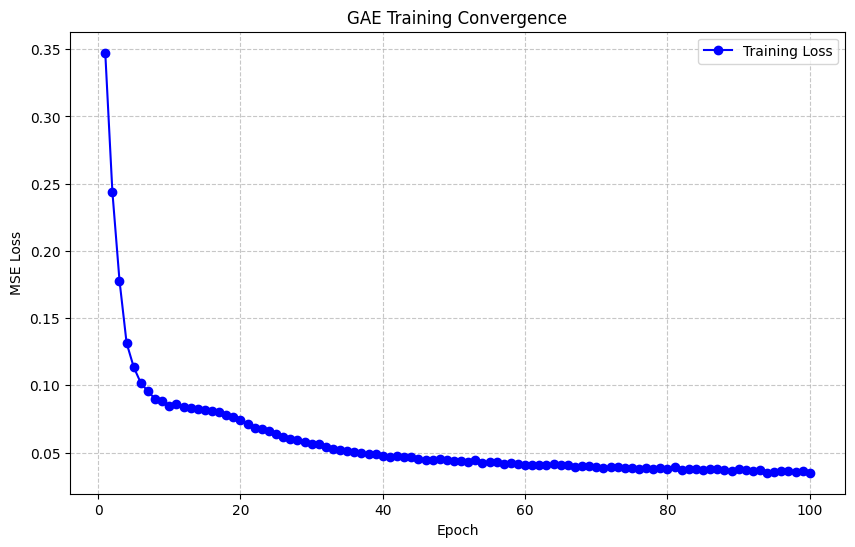

In [6]:
# Initialize Model
# Using 100 nodes, input_dim=100 (identity matrix features)
model = GraphAutoencoder(num_nodes=100, input_dim=100, hidden_dim=64, embedding_dim=128)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)
loss_fn = torch.nn.MSELoss()

num_epochs = 100
print("Starting GAE Training...")
train_losses = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    valid_batches = 0
    
    for batch_idx, (data, label) in enumerate(kb_dataloader):
        optimizer.zero_grad()
        
        try:
            target = data.y.view(data.num_graphs, 100, 100)
            reconstructed = model(data.x, data.edge_index, data.edge_weight, data.batch)
            
            if torch.isnan(reconstructed).any() or torch.isinf(reconstructed).any():
                print(f"Epoch {epoch+1}, Batch {batch_idx}: NaN/Inf detected")
                continue
            
            loss = loss_fn(reconstructed, target)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            total_loss += loss.item()
            valid_batches += 1
            
        except Exception as e:
            print(f"Error in batch {batch_idx}: {e}")
            continue
    
    if valid_batches > 0:
        avg_loss = total_loss / valid_batches
        train_losses.append(avg_loss)
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:03d}/{num_epochs} | Loss: {avg_loss:.6f}")

# Save the trained encoder (Now this will work!)
encoder_path = os.path.join(output_dir, 'gae_encoder.pth')
torch.save(model.encoder.state_dict(), encoder_path)
print(f"GAE Training Complete. Encoder weights saved to: {encoder_path}")

# --- VISUALIZATION ---
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', linestyle='-', color='b', label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('GAE Training Convergence')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()
